In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


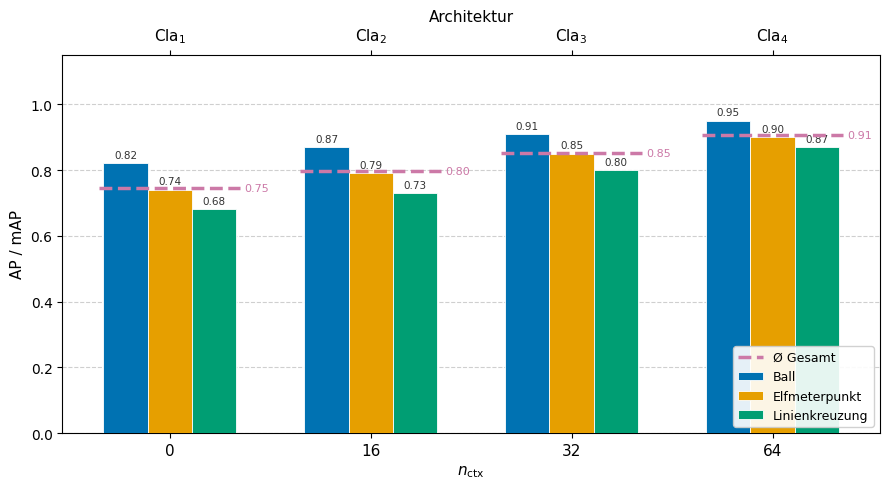

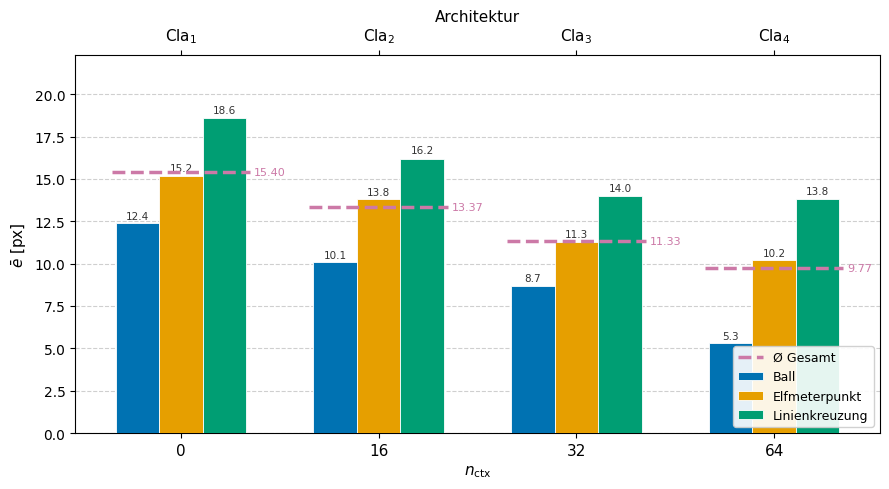

In [6]:


# ── Daten ──────────────────────────────────────────────────────────────────────
architectures = [
    r"$\mathrm{Cla}_1$",
    r"$\mathrm{Cla}_2$",
    r"$\mathrm{Cla}_3$",
    r"$\mathrm{Cla}_4$",
]

ctx_sizes = ["0", "16", "32", "64"]

classes = ["Ball", "Elfmeterpunkt", "Linienkreuzung"]


# AP-Werte [Architektur × Klasse]  →  hier Beispielwerte, einfach ersetzen
ap_values = {
    "Ball": [0.82, 0.87, 0.91, 0.95],
    "Elfmeterpunkt": [0.74, 0.79, 0.85, 0.9],
    "Linienkreuzung": [0.68, 0.73, 0.80, 0.87],
}

euc_values = {
    "Ball":           [12.4, 10.1, 8.7, 5.3],
    "Elfmeterpunkt":  [15.2, 13.8, 11.3, 10.2],
    "Linienkreuzung": [18.6, 16.2, 14.0, 13.8],
}

# Mittelwerte
map_values  = [np.mean([ap_values[cls][i]  for cls in classes]) for i in range(len(architectures))]
mean_euc    = [np.mean([euc_values[cls][i] for cls in classes]) for i in range(len(architectures))]



# ── Gemeinsame Layoutparameter ─────────────────────────────────────────────────
x         = np.arange(len(architectures))
n_classes = len(classes)
bar_width  = 0.22
offsets    = np.linspace(-(n_classes-1)/2, (n_classes-1)/2, n_classes) * bar_width
colors     = ["#0072B2", "#E69F00", "#009E73"]   # Okabe-Ito
mean_color = "#CC79A7"

# ── Hilfsfunktion: Achsen stylen ───────────────────────────────────────────────
def style_ax(ax, top_labels=None, top_xlabel=None):
    ax.set_xticks(x)
    ax.set_xticklabels(ctx_sizes, fontsize=11)
    ax.set_xlabel(r"$n_{\mathrm{ctx}}$", fontsize=11)
    ax.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    if top_labels is not None:
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())      # gleicher Bereich wie untere Achse
        ax_top.set_xticks(x)
        ax_top.set_xticklabels(top_labels, fontsize=11)
        ax_top.spines[["top", "right"]].set_visible(True)
        ax_top.spines[["bottom", "left"]].set_visible(False)
        if top_xlabel:
            ax_top.set_xlabel(top_xlabel, fontsize=11)

# ── Hilfsfunktion: Balken zeichnen ─────────────────────────────────────────────
def draw_bars(ax, data_dict, fmt=".2f"):
    for cls, color, offset in zip(classes, colors, offsets):
        bars = ax.bar(
            x + offset, data_dict[cls],
            width=bar_width, label=cls,
            color=color, edgecolor="white", linewidth=0.6, zorder=3,
        )
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ax.get_ylim()[1] * 0.01,
                f"{bar.get_height():{fmt}}",
                ha="center", va="bottom", fontsize=7.5, color="#333333",
            )


# ── Hilfsfunktion: Mittelwert-Segmente ────────────────────────────────────────
def draw_mean_segments(ax, mean_vals, label):
    for xi, mv in zip(x, mean_vals):
        ax.hlines(mv, xi - 0.35, xi + 0.35,
                colors=mean_color, linewidth=2.5, linestyle="--", zorder=4,
                label=label if xi == 0 else "")
        ax.text(xi + 0.37, mv, f"{mv:.2f}",
                ha="left", va="center", fontsize=8, color=mean_color)


# — Plot 1: AP / mAP ————————————————————————————————————————————————————————————
fig, ax = plt.subplots(figsize=(9, 5))
draw_bars(ax, ap_values, fmt=".2f")
ax.set_ylim(0, 1.15)
draw_mean_segments(ax, map_values, "Ø Gesamt")
style_ax(ax, top_labels=architectures, top_xlabel="Architektur")
ax.set_ylabel("AP / mAP", fontsize=11)
# ax.set_title("Average Precision (AP)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig("../../plots/n_ctx_ap_plot.pdf")

# — Plot 2: Euklidischer Fehler ————————————————————————————————————————————————
fig, ax = plt.subplots(figsize=(9, 5))
ymax = max(v for vals in euc_values.values() for v in vals) * 1.2
draw_bars(ax, euc_values, fmt=".1f")
ax.set_ylim(0, ymax)
draw_mean_segments(ax, mean_euc, "Ø Gesamt")
style_ax(ax, top_labels=architectures, top_xlabel="Architektur")
ax.set_ylabel(r"$\bar{e}$ [px]", fontsize=11)
# ax.set_title("Durchschnittlicher Euklidischer Fehler", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig("../../plots/n_ctx_euc_plot.pdf")

plt.tight_layout()
plt.show()